In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
data = pd.DataFrame({
    "hours_studied": np.random.randint(1,10,50),
    "attendance":np.random.randint(50,100,50)
})

data.head()


,hours_studied,attendance
0,3,99
1,8,58
2,5,87
3,4,69
4,5,54


In [7]:
x = data[["hours_studied","attendance"]]

model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(x)

data.head()

,hours_studied,attendance,cluster
0,3,99,2
1,8,58,1
2,5,87,0
3,4,69,1
4,5,54,1


In [8]:
score = silhouette_score(x, data["cluster"])
print("silhouette Score:",score)


silhouette Score: 0.5436171506506536


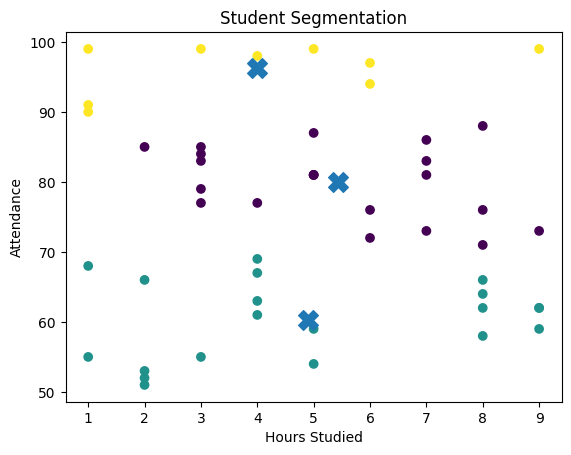

In [10]:
plt.scatter(data["hours_studied"],data["attendance"],c = data["cluster"])

centers = model.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s = 200)

plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Segmentation")
plt.show()



In [11]:
# Example: New student
# hours_studied = 6, attendance =80

new_student = [[6,80]]

predicted_cluster = model.predict(new_student)

print("New student belongs to Cluster:",predicted_cluster[0])

New student belongs to Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [12]:
data.groupby("cluster").mean()

,hours_studied,attendance
cluster,,
0,5.428571,79.952381
1,4.900000,60.300000
2,4.000000,96.222222
